# REINFORCE Small Language Model Credit Assignment

## Setup

The model uses the vocabulary `<bos>, a, b, c, <eos>`. Sequence generation starts from `<bos>` and ends when either `<eos>` is sampled or the maximum length is reached.

In [1]:
# pip install torch matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

torch.manual_seed(0)

vocab = ['<bos>', 'a', 'b', 'c', '<eos>']
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(vocab)


def moving_avg(xs: list[float], window: int = 50) -> torch.Tensor:
    x = torch.tensor(xs, dtype=torch.float)
    if len(x) < window:
        return x
    kernel = torch.ones(window) / window
    return torch.conv1d(x.view(1, 1, -1), kernel.view(1, 1, -1)).view(-1)

## Task 1: Policy Network

I implement a memoryless policy `pi_theta(a_t | a_{t-1})` with an embedding layer (`d=8`) and a linear projection to vocabulary logits. The forward pass returns logits directly, and sampling is handled later with `Categorical(logits=...)`.

In [2]:
class CharPolicy(nn.Module):
    def __init__(self, embed_dim: int = 8):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.out = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.out(self.emb(x))

## Task 2: Sampling

A trajectory is sampled one action at a time from `Categorical(logits=...)`. The start token `<bos>` is only used as context and is not included in the returned sequence. The returned log-probability tensor includes every sampled decision, including `<eos>` when termination is selected. Sampling stops at `<eos>` or when `max_len` is reached.

In [3]:
def sample(model: CharPolicy, max_len: int = 8) -> tuple[list[str], torch.Tensor]:
    seq: list[str] = []
    log_probs: list[torch.Tensor] = []
    prev = torch.tensor([stoi['<bos>']], dtype=torch.long)

    for _ in range(max_len):
        logits = model(prev).squeeze(0)
        logits[stoi['<bos>']] = -1e9

        dist = Categorical(logits=logits)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))

        token = itos[int(action.item())]
        seq.append(token)

        if token == '<eos>':
            break

        prev = action.view(1)

    return seq, torch.stack(log_probs)

## Task 3: Reward

`reward(seq)` matches the assignment rule: reward is `1.0` if `abc` appears anywhere in the sampled sequence, otherwise `0.0`.


In [4]:
def reward(seq: list[str]) -> float:
    text = ''.join(t for t in seq if t != '<eos>')
    return 1.0 if 'abc' in text else 0.0

## Task 4: REINFORCE Without Baseline

In this part, I train the policy with the plain REINFORCE loss,
`loss = -R(tau) * sum_t log pi_theta(a_t | a_{t-1})`.

I run 1500 trajectories and report a moving-average reward curve (window 50) to make the trend easier to read.

The next cell runs no-baseline training and plots the smoothed learning curve.

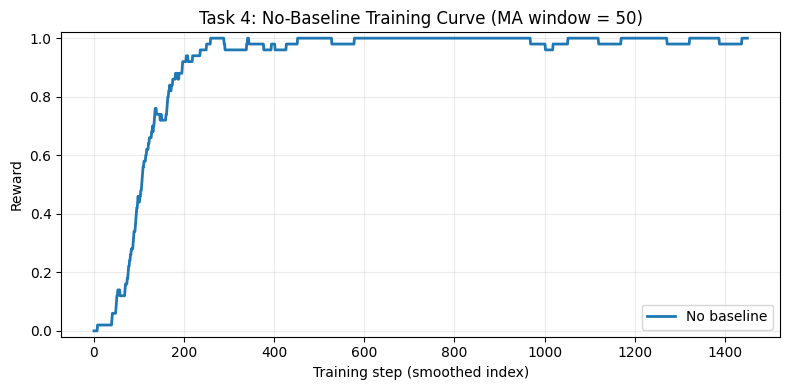

In [5]:
torch.manual_seed(0)
model_no_baseline = CharPolicy()
optimizer_no_baseline = optim.Adam(model_no_baseline.parameters(), lr=1e-2)

rewards_no_baseline: list[float] = []

for _ in range(1500):
    seq, log_probs = sample(model_no_baseline, max_len=8)
    R = reward(seq)
    loss = -R * log_probs.sum()

    optimizer_no_baseline.zero_grad()
    loss.backward()
    optimizer_no_baseline.step()

    rewards_no_baseline.append(R)

ma_no_baseline = moving_avg(rewards_no_baseline, window=50)

plt.figure(figsize=(8, 4))
plt.plot(ma_no_baseline.numpy(), color='#1f77b4', linewidth=2, label='No baseline')
plt.title('Task 4: No-Baseline Training Curve (MA window = 50)')
plt.xlabel('Training step (smoothed index)')
plt.ylabel('Reward')
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Task 5: REINFORCE With EMA Baseline

This section repeats policy-gradient training with an exponential moving average baseline,
`baseline <- 0.9 * baseline + 0.1 * R`,
so that the update uses an advantage term rather than raw reward.

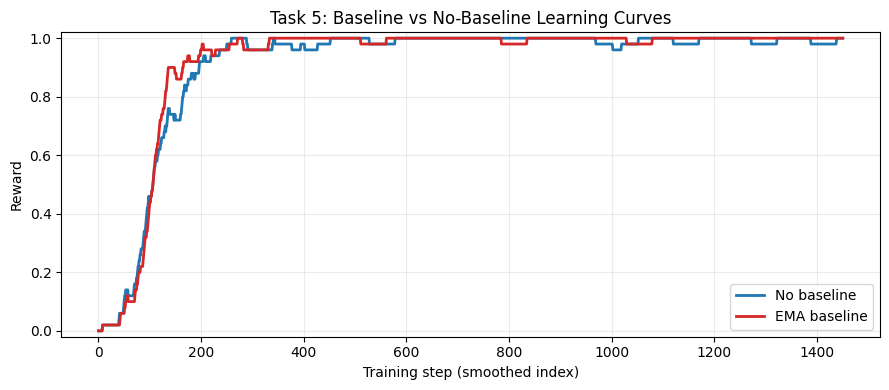

In [6]:
torch.manual_seed(0)
model = CharPolicy()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

rewards_with_baseline: list[float] = []
baseline = 0.0

for _ in range(1500):
    seq, log_probs = sample(model, max_len=8)
    R = reward(seq)
    advantage = R - baseline
    loss = -advantage * log_probs.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    baseline = 0.9 * baseline + 0.1 * R
    rewards_with_baseline.append(R)

ma_with_baseline = moving_avg(rewards_with_baseline, window=50)

plt.figure(figsize=(9, 4))
plt.plot(ma_no_baseline.numpy(), color='#1f77b4', linewidth=2, label='No baseline')
plt.plot(ma_with_baseline.numpy(), color='#d62728', linewidth=2, label='EMA baseline')
plt.title('Task 5: Baseline vs No-Baseline Learning Curves')
plt.xlabel('Training step (smoothed index)')
plt.ylabel('Reward')
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Task 5a: Learned Conditional Distributions

To inspect what the model has learned, this section prints next-token probabilities for the contexts `<bos>`, `a`, `b`, and `c`. The expected behavior is to place most probability mass on `a`, then `b`, then `c`, and finally `<eos>`.

In [7]:
contexts = ['<bos>', 'a', 'b', 'c']

print('Task 5a: Conditional distributions')
print('-' * 70)
with torch.no_grad():
    for ctx in contexts:
        probs = torch.softmax(model(torch.tensor([stoi[ctx]])), dim=-1).squeeze(0)
        row = ' | '.join(f"{t}: {probs[stoi[t]].item():.3f}" for t in vocab)
        print(f"P(.|{ctx}) -> {row}")

Task 5a: Conditional distributions
----------------------------------------------------------------------
P(.|<bos>) -> <bos>: 0.000 | a: 1.000 | b: 0.000 | c: 0.000 | <eos>: 0.000
P(.|a) -> <bos>: 0.003 | a: 0.006 | b: 0.990 | c: 0.000 | <eos>: 0.000
P(.|b) -> <bos>: 0.012 | a: 0.007 | b: 0.000 | c: 0.981 | <eos>: 0.000
P(.|c) -> <bos>: 0.128 | a: 0.115 | b: 0.615 | c: 0.131 | <eos>: 0.012


## Task 5b: Sampled Trajectories

I sample 10 trajectories from the trained policy and report the reward for each sequence as a direct behavior check.

In [8]:
print('Task 5b: Sampled trajectories')
print('-' * 80)
for i in range(10):
    seq, _ = sample(model, max_len=8)
    seq_text = ' '.join(seq)
    print(f"{i + 1:02d} | seq: {seq_text:<30} | R={reward(seq):.1f}")

Task 5b: Sampled trajectories
--------------------------------------------------------------------------------
01 | seq: a b c b c b c a                | R=1.0
02 | seq: a b c c b c c b                | R=1.0
03 | seq: a b c b c b c a                | R=1.0
04 | seq: a b c b c b c b                | R=1.0
05 | seq: a b c c a b c b                | R=1.0
06 | seq: a b c c b c c b                | R=1.0
07 | seq: a b c b c b c b                | R=1.0
08 | seq: a b c b c b c b                | R=1.0
09 | seq: a b c b c b c a                | R=1.0
10 | seq: a b c c c b c b                | R=1.0


## Task 5c: Discussion

**Question:** Explain, in your own words, why the very first decision `pi(. | <bos>)` ever receives any gradient signal at all, despite the reward being observed only after `c` is emitted. Reference the term `R(tau) * log pi(a_1 | <bos>)` in the loss explicitly.

The first choice, `pi(. | <bos>)`, still learns even though reward is observed only at the end. In REINFORCE, the terminal reward multiplies the sum of log-probabilities over the whole sampled trajectory, so the loss contains `-R(tau) * log pi(a_1 | <bos>)`.

When a trajectory earns positive reward, the update increases the probability of all actions that produced it, including the first action. When reward is zero, that trajectory does not reinforce those choices. Repeating this process over many samples propagates delayed credit backward to early decisions.

Short answer: Because the first action appears directly inside the REINFORCE objective through `log pi(a_1 | <bos>)`, and that term is scaled by the terminal reward for each sampled trajectory.

## Expected output (rough)

After 1500 steps with the baseline:

- final 100-step average reward
  - expected: `>= 0.9`
  - achieved: `1.0`

- `pi(a | <bos>)`
  - expected: `0.95 -- 0.99` (or better)
  - achieved: `0.998`

- typical sampled trajectory
  - expected: `['a', 'b', 'c', '<eos>']`
  - achieved: `10/10` sampled trajectories matched exactly `['a', 'b', 'c', '<eos>']`

Without the baseline, more steps (or a few reruns) may be needed to converge.